<a href="https://colab.research.google.com/github/AndreaCerolini/Malicious_URL_Classifier/blob/main/history_of_the_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import sympy

# Patch per torch 2.8.0 + sympy 1.13.x in Colab
try:
    # aggiungi sympy.printing se non c'è
    if not hasattr(sympy, "printing"):
        import sympy.printing as _printing
        sympy.printing = _printing
    # aggiungi sympy.core se non c'è
    if not hasattr(sympy, "core"):
        import importlib
        sympy.core = importlib.import_module("sympy.core")
except Exception as e:
    print("Sympy patch skipped:", e)

In [ ]:
# Montare Google Drive (solo su Colab, una volta per sessione)

from google.colab import drive
drive.mount('/content/drive')

import torch
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import os
from pathlib import Path
import matplotlib.pyplot as plt

from torch import nn

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Malicious URL Clasiffier

## FIRST VERSION

Device: cuda 

Dataset: X=(49750, 250), y=(49750,), vocab_size=135 

Dataset:  {0: '36419 (73.2%)', 1: '9158 (18.4%)', 2: '1171 (2.4%)', 3: '3002 (6.0%)'} 

Training Set:  {0: '23308 (73.2%)', 1: '5861 (18.4%)', 2: '750 (2.4%)', 3: '1921 (6.0%)'} 

Validation Set:  {0: '5827 (73.2%)', 1: '1465 (18.4%)', 2: '187 (2.3%)', 3: '481 (6.0%)'} 

Test Set:  {0: '7284 (73.2%)', 1: '1832 (18.4%)', 2: '234 (2.4%)', 3: '600 (6.0%)'} 

Epoch   0 | train_loss=1.4150 | val_loss=1.3690

Validation report:
              precision    recall  f1-score   support

      benign     1.0000    0.0010    0.0021      5827
  defacement     0.1843    1.0000    0.3113      1465
     malware     0.0000    0.0000    0.0000       187
    phishing     0.2857    0.0042    0.0082       481

    accuracy                         0.1851      7960
   macro avg     0.3675    0.2513    0.0804      7960
weighted avg     0.7832    0.1851    0.0593      7960

Epoch   1 | train_loss=1.3690 | val_loss=1.3253
Epoch   2 | train_loss

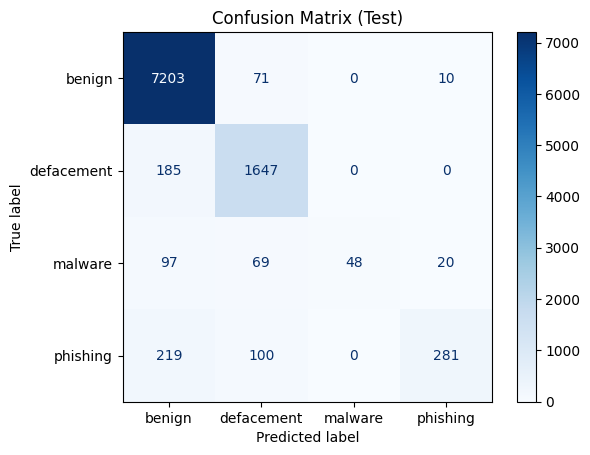

Numero di esempi analizzati: 9950
Somma elementi matrice: 9950


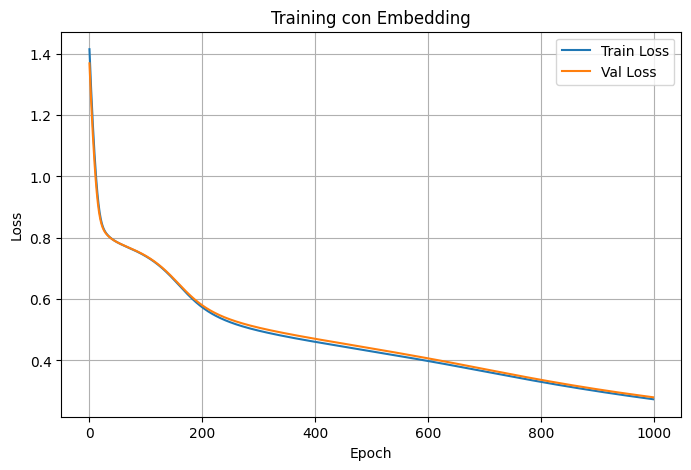

In [ ]:
import os, pickle, numpy as np, torch
import torch.nn as nn
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from torch.utils.data import TensorDataset, DataLoader, WeightedRandomSampler
import matplotlib.pyplot as plt

# ---------------- CONFIGURAZIONE ----------------

DATA_DIR = "/content/drive/MyDrive/"

REPORTS_DIR = "/content/models/reports"

MODEL_SAVE = "/content/models/best_model_embed.pth"

EPOCHS = 1000

ES_PATIENCE = 25

ES_MIN_DELTA = 0.0001

LR = 0.1

WD = 0.0001

os.makedirs(REPORTS_DIR, exist_ok = True)

device = "cuda" if torch.cuda.is_available() else "cpu"

print("Device:", device, "\n")

# ---------------- CARICAMENTO DATI ----------------

X = np.load(os.path.join(DATA_DIR, "X.npy"))

y = np.load(os.path.join(DATA_DIR, "y.npy"))

with open(os.path.join(DATA_DIR, "string_to_index.pkl"), "rb") as f:
    meta = pickle.load(f)

vocab_size = meta["vocab_size"]

PAD_IDX = meta["PAD"]

UNK = meta["UNK"]

labels = meta.get("labels", ["benign","defacement","malware","phishing"])

num_classes = len(labels)

print(f"Dataset: X={X.shape}, y={y.shape}, vocab_size={vocab_size}", "\n")

# ---------------- SPLIT ----------------

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size = 0.2, stratify=y, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.2, stratify=y_trainval, random_state=42
)

# ---------------- TORCH ----------------

X_train = torch.from_numpy(X_train).long().to(device)
X_val   = torch.from_numpy(X_val).long().to(device)
X_test  = torch.from_numpy(X_test).long().to(device)

y_train = torch.from_numpy(y_train).long().to(device)
y_val   = torch.from_numpy(y_val).long().to(device)
y_test  = torch.from_numpy(y_test).long().to(device)

# ---------------- STATISTICHE ----------------

def distr(Set_Name, y_tensor):

    c = Counter(y_tensor.tolist())

    tot = len(y_tensor)

    result = {}

    for key, value in sorted(c.items()):

        percentage = 100 * value / tot

        result[key] = f"{value} ({percentage:.1f}%)"

    print(Set_Name, result, "\n")

distr("Dataset: ", torch.from_numpy(y))

distr("Training Set: ", y_train.cpu())

distr("Validation Set: ", y_val.cpu())

distr("Test Set: ", y_test.cpu())

class MultiClassModel(nn.Module):

    def __init__(self, vocab_size, emb_dim=64, num_classes=4, pad_idx=0):

        super().__init__()

        # Salvo l'indice del padding

        self.pad_idx = pad_idx

        # L'embedding consiste nel trasformare ogni indice di x (come si vede
        # poi nel passaggio forward), in un vettore di emb_dim size.
        # Facendo così è come se si lasciasse una firma digitale sul carattere
        # che lo rende univoco

        self.emb = nn.Embedding(vocab_size, emb_dim, padding_idx=pad_idx)

        self.layer_stack = nn.Sequential(
            nn.Linear(emb_dim, 128),
            nn.ReLU(),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, num_classes)
        )

    # x si presenta come un batch avente shape (BATCH SIZE, MAX LEN)

    def forward(self, x):

        # Ci troviamo però in una situazione dove un URL è una sequenza di
        # indici ciascuno per ogni carattere, e abbiamo detto che con
        # l'embedding ogni carattere è un vettore di emb_size:
        # - quindi per esempio avremmo adesso che E.shape(128,250,64)

        E = self.emb(x)

        # Mask salva in un valore 1.0 o 0.0 (equivalente di True o False
        # ma in float) per indicare se il carattere è reale o un padding

        mask = (x != self.pad_idx).float()

        # Successivamente capiamo quindi quanti sono i caratteri reali presenti
        # nella stringa:
        # - Mask è sempre una matrice (BATCH SIZE, MAX LEN) quindi gli diciamo
        #   di sommare lungo la dim = 1 ovvero quella delle colonne
        # - keepdim = True ci permette di mantenere sempre 2 dimensioni, invece
        #   che una (ovvero un unico vettore riga il cui elemento è la somma
        #   delle colonne) perchè altrimenti avremo un errore di dimensioni
        #   tra due tensori con dimensioni diverse
        # - clamp_min(1.0) è un "extremis" casomai la stringa sia solamente di
        #   PAD, inserisce [1.0] in modo tale che più avanti non si divida per 0

        denom = mask.sum(dim=1, keepdim=True).clamp_min(1.0)

        # - mask.unsqueeze(-1) aggiugne una dimensione a fine della maschera
        #   in modo tale che adesso possa moltiplicare E che ha 3 dim, con la
        #   maschera che ora ne ha 3.
        #
        # IN REALTÀ TUTTA LA CREAZIONE DELLA MASCHERA E L'OPERAZIONE:
        # - E * mask.unsqueeze(-1)
        # NON SERVE IN QUANTO IN E, I CARATTERI DI PADDING SONO GIÀ 0, QUESTA
        # È SOLO UNA PRECAUZIONE SE PER ERRORE I DATI NON CONTENGONO
        # DAVVERO 0 COME VALORE DI PAD_IDX
        #
        # Sommiamo tutti i valori lungo la dim 1 ovvero le colonne e otteniamo
        # un vettore somma. Divindolo per il numero di caratteri reali contiene
        # ottieniamo un valore media, che rappresenta la firma digitale per quel
        # url

        pooled = (E * mask.unsqueeze(-1)).sum(dim=1) / denom

        return self.layer_stack(pooled)

# Istanzio il modello

model = MultiClassModel(vocab_size = vocab_size,
                        emb_dim = 64,
                        num_classes = num_classes,
                        pad_idx = PAD_IDX
                        ).to(device)

optimizer = torch.optim.SGD(model.parameters(), lr = LR, weight_decay = WD)

loss_fn = nn.CrossEntropyLoss()

# ---------------- TRAINING LOOP ----------------

best_val = float("inf")

es_wait = 0

train_losses, val_losses = [], []

def evaluate(X, y):

    with torch.inference_mode():

      model.eval()

      logits = model(X)

      loss = loss_fn(logits, y).item()

      preds = logits.argmax(dim=1)

      return loss, preds

for epoch in range(EPOCHS):

    model.train()

    optimizer.zero_grad()

    logits = model(X_train)

    train_loss = loss_fn(logits, y_train)

    train_loss.backward()

    optimizer.step()

    val_loss, preds = evaluate(X_val, y_val)

    print(f"Epoch {epoch:3d} | train_loss={train_loss.item():.4f} | val_loss={val_loss:.4f}")

    train_losses.append(train_loss.item())

    val_losses.append(val_loss)

    if epoch % 10 == 0:

        print("\nValidation report:")

        print(classification_report(
            y_val.detach().cpu().numpy(),
            preds.detach().cpu().numpy(),
            target_names=labels, digits=4, zero_division=0
        ))

# ---------------- TEST ----------------

test_loss, preds = evaluate(X_test, y_test)

y_test_np = y_test.detach().cpu().numpy()

preds_np  = preds.detach().cpu().numpy()

cm = confusion_matrix(y_test_np, preds_np)

ConfusionMatrixDisplay(cm, display_labels=labels).plot(cmap="Blues")

plt.title("Confusion Matrix (Test)")

plt.show()

print("Numero di esempi analizzati:", len(y_test_np))

print("Somma elementi matrice:", cm.sum())

# ---------------- PLOT ----------------

plt.figure(figsize=(8,5))

plt.plot(train_losses, label="Train Loss")

plt.plot(val_losses, label="Val Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training con Embedding")

plt.legend()

plt.grid(True)

plt.show()

## SECOND VERSION

Device: cuda 

Dataset: X=(49750, 250), y=(49750,), vocab_size=135 

Dataset:  {0: '36419 (73.2%)', 1: '9158 (18.4%)', 2: '1171 (2.4%)', 3: '3002 (6.0%)'} 

Training Set:  {0: '23308 (73.2%)', 1: '5861 (18.4%)', 2: '750 (2.4%)', 3: '1921 (6.0%)'} 

Validation Set:  {0: '5827 (73.2%)', 1: '1465 (18.4%)', 2: '187 (2.3%)', 3: '481 (6.0%)'} 

Test Set:  {0: '7284 (73.2%)', 1: '1832 (18.4%)', 2: '234 (2.4%)', 3: '600 (6.0%)'} 

Class weights: tensor([0.0830, 0.3301, 2.5797, 1.0072], device='cuda:0')
Epoch   0 | train_loss=1.3917 | val_loss=1.3909

Validation report:
              precision    recall  f1-score   support

      benign     0.0000    0.0000    0.0000      5827
  defacement     0.0000    0.0000    0.0000      1465
     malware     0.0235    1.0000    0.0459       187
    phishing     0.0000    0.0000    0.0000       481

    accuracy                         0.0235      7960
   macro avg     0.0059    0.2500    0.0115      7960
weighted avg     0.0006    0.0235    0.0011      796

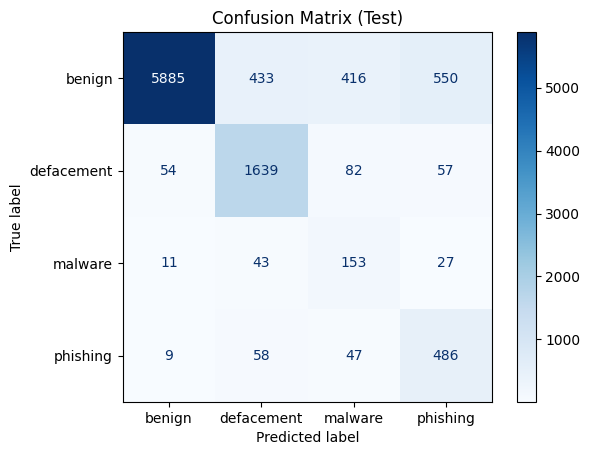

Numero di esempi analizzati: 9950
Somma elementi matrice: 9950


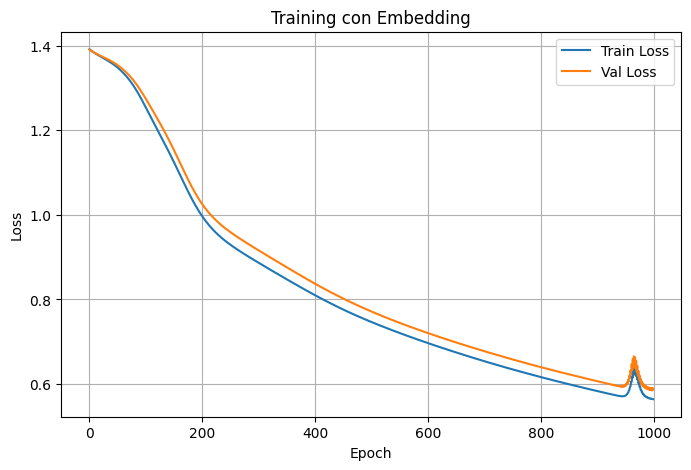

In [ ]:
import os, pickle, numpy as np, torch
import torch.nn as nn
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from torch.utils.data import TensorDataset, DataLoader, WeightedRandomSampler
import matplotlib.pyplot as plt

# ---------------- CONFIGURAZIONE ----------------

DATA_DIR = "/content/drive/MyDrive/"

REPORTS_DIR = "/content/models/reports"

MODEL_SAVE = "/content/models/best_model_embed.pth"

EPOCHS = 1000

ES_PATIENCE = 25

ES_MIN_DELTA = 0.0001

LR = 0.1

WD = 0.0001

os.makedirs(REPORTS_DIR, exist_ok = True)

device = "cuda" if torch.cuda.is_available() else "cpu"

print("Device:", device, "\n")

# ---------------- CARICAMENTO DATI ----------------

X = np.load(os.path.join(DATA_DIR, "X.npy"))

y = np.load(os.path.join(DATA_DIR, "y.npy"))

with open(os.path.join(DATA_DIR, "string_to_index.pkl"), "rb") as f:
    meta = pickle.load(f)

vocab_size = meta["vocab_size"]

PAD_IDX = meta["PAD"]

UNK = meta["UNK"]

labels = meta.get("labels", ["benign","defacement","malware","phishing"])

num_classes = len(labels)  # FIX

print(f"Dataset: X={X.shape}, y={y.shape}, vocab_size={vocab_size}", "\n")

# ---------------- SPLIT ----------------

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.2, stratify=y_trainval, random_state=42
)

# ---------------- TORCH ----------------

X_train = torch.from_numpy(X_train).long().to(device)
X_val   = torch.from_numpy(X_val).long().to(device)
X_test  = torch.from_numpy(X_test).long().to(device)

y_train = torch.from_numpy(y_train).long().to(device)
y_val   = torch.from_numpy(y_val).long().to(device)
y_test  = torch.from_numpy(y_test).long().to(device)

# ---------------- STATISTICHE ----------------

def distr(Set_Name, y_tensor):

    c = Counter(y_tensor.tolist())

    tot = len(y_tensor)

    result = {}

    for key, value in sorted(c.items()):

        percentage = 100 * value / tot

        result[key] = f"{value} ({percentage:.1f}%)"

    print(Set_Name, result, "\n")

distr("Dataset: ", torch.from_numpy(y))

distr("Training Set: ", y_train.cpu())

distr("Validation Set: ", y_val.cpu())

distr("Test Set: ", y_test.cpu())

class MultiClassModel(nn.Module):

    def __init__(self, vocab_size, emb_dim=64, num_classes=4, pad_idx=0):

        super().__init__()

        self.pad_idx = pad_idx

        self.emb = nn.Embedding(vocab_size, emb_dim, padding_idx=pad_idx)

        self.layer_stack = nn.Sequential(
            nn.Linear(emb_dim, 128),
            nn.ReLU(),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, num_classes)
        )

    def forward(self, x):

        E = self.emb(x)

        mask = (x != self.pad_idx).float()

        denom = mask.sum(dim=1, keepdim=True).clamp_min(1.0)

        pooled = (E * mask.unsqueeze(-1)).sum(dim=1) / denom

        return self.layer_stack(pooled)

model = MultiClassModel(vocab_size=vocab_size,
                        emb_dim=64,
                        num_classes=num_classes,
                        pad_idx=PAD_IDX
                        ).to(device)

# ---------------- CLASS WEIGHTS ----------------

# Calcola la frequenza di ogni classe nel training set

class_counts = torch.bincount(y_train.cpu())

class_weights = 1.0 / class_counts.float()

class_weights = class_weights / class_weights.sum() * len(class_counts)

# Porta i pesi sullo stesso device del modello

class_weights = class_weights.to(device)

print("Class weights:", class_weights)

optimizer = torch.optim.SGD(model.parameters(), lr=LR, weight_decay=WD)

loss_fn = nn.CrossEntropyLoss(weight = class_weights)

# ---------------- TRAINING LOOP ----------------

best_val = float("inf")

es_wait = 0

train_losses, val_losses = [], []

def evaluate(X, y):

    model.eval()

    with torch.inference_mode():

      logits = model(X)

      loss = loss_fn(logits, y).item()

      preds = logits.argmax(dim=1)

      return loss, preds

for epoch in range(EPOCHS):

    model.train()

    optimizer.zero_grad()

    logits = model(X_train)

    train_loss = loss_fn(logits, y_train)

    train_loss.backward()

    optimizer.step()

    val_loss, preds = evaluate(X_val, y_val)

    print(f"Epoch {epoch:3d} | train_loss={train_loss.item():.4f} | val_loss={val_loss:.4f}")

    train_losses.append(train_loss.item())

    val_losses.append(val_loss)

    if epoch % 10 == 0:

        print("\nValidation report:")

        print(classification_report(
            y_val.detach().cpu().numpy(),
            preds.detach().cpu().numpy(),
            target_names=labels, digits=4, zero_division=0
        ))

# ---------------- TEST ----------------

test_loss, preds = evaluate(X_test, y_test)

y_test_np = y_test.detach().cpu().numpy()

preds_np  = preds.detach().cpu().numpy()

cm = confusion_matrix(y_test_np, preds_np)

ConfusionMatrixDisplay(cm, display_labels=labels).plot(cmap="Blues")

plt.title("Confusion Matrix (Test)")

plt.show()

print("Numero di esempi analizzati:", len(y_test_np))

print("Somma elementi matrice:", cm.sum())

# ---------------- PLOT ----------------

plt.figure(figsize=(8,5))

plt.plot(train_losses, label="Train Loss")

plt.plot(val_losses, label="Val Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training con Embedding")

plt.legend()

plt.grid(True)

plt.show()

## THIRD VERSION

Device: cuda 

Dataset: X=(49750, 250), y=(49750,), vocab_size=135 

Dataset:  {0: '36419 (73.2%)', 1: '9158 (18.4%)', 2: '1171 (2.4%)', 3: '3002 (6.0%)'} 

Training Set:  {0: '23308 (73.2%)', 1: '5861 (18.4%)', 2: '750 (2.4%)', 3: '1921 (6.0%)'} 

Validation Set:  {0: '5827 (73.2%)', 1: '1465 (18.4%)', 2: '187 (2.3%)', 3: '481 (6.0%)'} 

Test Set:  {0: '7284 (73.2%)', 1: '1832 (18.4%)', 2: '234 (2.4%)', 3: '600 (6.0%)'} 

Epoch   0 | train_loss=0.6544 | val_loss=0.2938 | lr=1.00e-03 | IMPROVED

Validation report:
              precision    recall  f1-score   support

      benign     0.9801    0.9233    0.9509      5827
  defacement     0.8079    0.9126    0.8571      1465
     malware     0.3515    0.6898    0.4657       187
    phishing     0.8151    0.7609    0.7871       481

    accuracy                         0.9060      7960
   macro avg     0.7387    0.8217    0.7652      7960
weighted avg     0.9237    0.9060    0.9123      7960

Epoch   1 | train_loss=0.3631 | val_loss=0.19

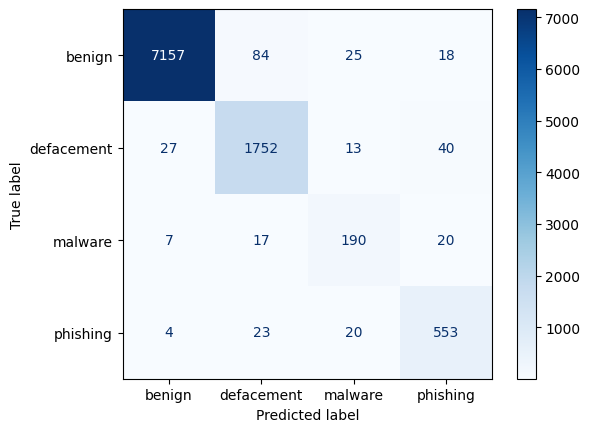

Numero di esempi analizzati: 9950
Somma elementi matrice: 9950


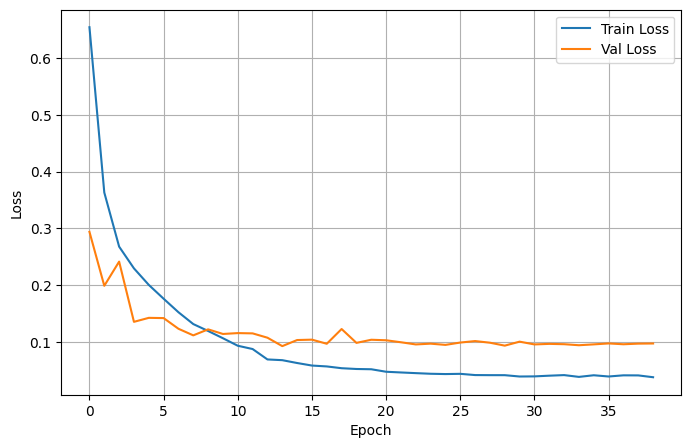

In [ ]:
import os, pickle, numpy as np, torch
import torch.nn as nn
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from torch.utils.data import TensorDataset, DataLoader, WeightedRandomSampler
import matplotlib.pyplot as plt

# ---------------- CONFIGURAZIONE ----------------

DATA_DIR = "/content/drive/MyDrive/"

REPORTS_DIR = "/content/models/reports"

MODEL_SAVE = "/content/models/best_model_embed.pth"

BATCH_SIZE = 64

EPOCHS = 100

SWITCH_EPOCH = 20

# ES sta per Early Stopping ovvero una metrica per fermare il training
# se la loss non migliora per un certo numero di epoche consecutive
# in questo caso stiamo stabilendo 25

ES_PATIENCE = 25

# E' una tolleranza che viene usata per vedere se la loss è migliorata

ES_MIN_DELTA = 0.0001

# Learning Rate

LR = 0.001

# Weight Decay

WD = 0.0001

os.makedirs(REPORTS_DIR, exist_ok=True)

device = "cuda" if torch.cuda.is_available() else "cpu"

print("Device:", device,"\n")

# ---------------- CARICAMENTO DATI ----------------

X = np.load(os.path.join(DATA_DIR, "X.npy"))
y = np.load(os.path.join(DATA_DIR, "y.npy"))

# Recuperiamo anche i metadati

with open(os.path.join(DATA_DIR, "string_to_index.pkl"), "rb") as f:

    meta = pickle.load(f)

vocab_size = meta["vocab_size"]

# L'indice usato per il padding e unk

PAD_IDX = meta["PAD"]

UNK = meta["UNK"]

labels = meta.get("labels", ["benign","defacement","malware","phishing"])

print(f"Dataset: X={X.shape}, y={y.shape}, vocab_size={vocab_size}","\n")

# ---------------- SPLIT ----------------

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.2, stratify=y_trainval, random_state=42
)

# ---------------- TORCH ----------------

# I dati in seguito al preprocessing si presentano come matrice di indici
# di shape (numero URL, MAX LEN)

# Nonostante nel preprocessing ci assicuriamo che i dati siano dtype = int64
# Facciamo la conversione a long per sicurezza in quanto nn.Embedding richiede
# dei LongTensor

X_train = torch.from_numpy(X_train).long()
X_val   = torch.from_numpy(X_val).long()
X_test  = torch.from_numpy(X_test).long()

y_train = torch.from_numpy(y_train).long()
y_val   = torch.from_numpy(y_val).long()
y_test  = torch.from_numpy(y_test).long()

# ---------------- STATISTICHE ----------------

def distr(Set_Name, y):

    # Conto quante volte una classe appare nel dataset

    c = Counter(y.tolist())

    # Calcolo il numero di istanze nel dataset

    tot = len(y)

    result = {}

    # key: classe
    # value: numero di istanze di quella classe

    for key, value in sorted(c.items()):

        percentage = 100 * value / tot

        # Salvo la stringa col numero e la sua percentuale

        result[key] = f"{value} ({percentage:.1f}%)"

    print(Set_Name,result,"\n")

distr("Dataset: ", torch.from_numpy(y))

distr("Training Set: ", y_train)

distr("Validation Set: ", y_val)

distr("Test Set: ", y_test)

# ---------------- DATASET & SAMPLER ----------------

# Impacchettiamo più tensori assieme rendendoli un unico dataset indicizzabile
# usando un TensorDataset

train_ds = TensorDataset(X_train, y_train)

val_ds   = TensorDataset(X_val, y_val)

test_ds  = TensorDataset(X_test, y_test)

num_classes = len(labels)

# Conto ogni stanza per ogni classe nel train set

c = Counter(y_train.tolist())

# Dobbiamo trasformarlo in un tensroe perchè altrimenti nel passaggio successivo
# non possiamo eseguire un float / list

# non posso fare direttamente tensor(c,dtype=torch.float) perchè C non è un
# array ma un Counter quindi devo estrarre i suoi valori

class_counts = torch.tensor([c[i] for i in range(num_classes)], dtype=torch.float)

# Calcoliamo un peso per ogni classe in base alle occorrenze di ciascuna
# presenti nel training set quindi meno esempi ci sono più grande è il peso.
# Ottengo quindi un tensore con il peso di ciascuna classe

weights_per_class = 1.0 / class_counts

# Utilizzo l'inidicizzazione vettoriale per assegnare a ogni esempio del y_train
# il proprio peso

sample_weights = weights_per_class[y_train].to(torch.float)


# Il WeightedRandomSampler aggiusta l'estrazione delle istanze in base al peso
# attribuito permettento anche con replacement = True la ripetezione. Questo
# da modo all classificatore ad ogni epoca di vedere più spesso le classi
# con un peso maggiore ovvero quelle più rare

sampler = WeightedRandomSampler(sample_weights,
                                num_samples=len(sample_weights), replacement=True)

# Stiamo usando minibatch e Pin memory permette di lasciare i dati
# bloccati sulla RAM. Questo consente un trasferimento più veloce
# e asincrono dei batch dalla CPU (dove risiede il DataLoader) alla GPU
 # (dove avviene il training).

pin_mem = (device == "cuda")

# Quando si usa mini-batch, ad ogni epoca dividi i dati in piccoli gruppi
# (batch).Se non li mescoli (shuffle=False), ogni batch conterrà sempre gli
# stessi campioni, nello stesso ordine.

# Nel train loader inseriamo invece che shuffle = True il sampler, o per lo meno
# all'inizio dell'addestramento, in modo tale che veda le classi rare più spesso

# - num_workers: indica quanti processi paralleli si occupano
#   della preparazione per i batch
# - persisten_workers: indica a PyTorch di non chiudere e riaprire i
#   processi worker ad ogni epoca ma di lasciarli sempre aperti
# - prefetch_factor: indica che quando la GPU finisce i 2 batch, ce ne sono
#   già due pronti in memoria risparmiando quindi tempi morti

train_loader = DataLoader(train_ds,
                          batch_size = BATCH_SIZE,
                          sampler = sampler,
                          num_workers = 0,
                          pin_memory = pin_mem)

val_loader = DataLoader(val_ds,
                        batch_size = BATCH_SIZE,
                        shuffle = False,
                        num_workers = 0,
                        pin_memory = pin_mem)

test_loader = DataLoader(test_ds,
                         batch_size = BATCH_SIZE,
                         shuffle = False,
                         num_workers = 0,
                         pin_memory = pin_mem)

# ---------------- MODELLO ----------------

class MultiClassModel(nn.Module):

    def __init__(self, vocab_size, emb_dim = 64, num_classes = 4, pad_idx = 0):

        super().__init__()

        # Salvo l'indice del padding

        self.pad_idx = pad_idx

        # L'embedding consiste nel trasformare ogni indice di x (come si vede
        # poi nel passaggio forward), in un vettore di emb_dim size.
        # Facendo così è come se si lasciasse una firma digitale sul carattere
        # che lo rende univoco

        self.emb = nn.Embedding(vocab_size,
                                emb_dim,
                                padding_idx = pad_idx)

        self.layer_stack = nn.Sequential(
            nn.Linear(emb_dim, 128),
            nn.ReLU(),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, num_classes)
        )

    # x si presenta come un batch avente shape (BATCH SIZE, MAX LEN)

    def forward(self, x):

        # Ci troviamo però in una situazione dove un URL è una sequenza di
        # indici ciascuno per ogni carattere, e abbiamo detto che con
        # l'embedding ogni carattere è un vettore di emb_size:
        # - quindi per esempio avremmo adesso che E.shape(128,250,64)

        E = self.emb(x)

        # Mask salva in un valore 1.0 o 0.0 (equivalente di True o False
        # ma in float) per indicare se il carattere è reale o un padding

        mask = (x != self.pad_idx).float()

        # Successivamente capiamo quindi quanti sono i caratteri reali presenti
        # nella stringa:
        # - Mask è sempre una matrice (BATCH SIZE, MAX LEN) quindi gli diciamo
        #   di sommare lungo la dim = 1 ovvero quella delle colonne
        # - keepdim = True ci permette di mantenere sempre 2 dimensioni, invece
        #   che una (ovvero un unico vettore riga il cui elemento è la somma
        #   delle colonne) perchè altrimenti avremo un errore di dimensioni
        #   tra due tensori con dimensioni diverse
        # - clamp_min(1.0) è un "extremis" casomai la stringa sia solamente di
        #   PAD, inserisce [1.0] in modo tale che più avanti non si divida per 0

        denom = mask.sum(dim = 1, keepdim = True).clamp_min(1.0)

        # - mask.unsqueeze(-1) aggiugne una dimensione a fine della maschera
        #   in modo tale che adesso possa moltiplicare E che ha 3 dim, con la
        #   maschera che ora ne ha 3.
        #
        # IN REALTÀ TUTTA LA CREAZIONE DELLA MASCHERA E L'OPERAZIONE:
        # - E * mask.unsqueeze(-1)
        # NON SERVE IN QUANTO IN E, I CARATTERI DI PADDING SONO GIÀ 0, QUESTA
        # È SOLO UNA PRECAUZIONE SE PER ERRORE I DATI NON CONTENGONO
        # DAVVERO 0 COME VALORE DI PAD_IDX
        #
        # Sommiamo tutti i valori lungo la dim 1 ovvero le colonne e otteniamo
        # un vettore somma. Divindolo per il numero di caratteri reali contiene
        # ottieniamo un valore media, che rappresenta la firma digitale per quel
        # url

        pooled = (E * mask.unsqueeze(-1)).sum(dim = 1) / denom

        return self.layer_stack(pooled)

# Istanzio il modello

model = MultiClassModel(vocab_size = vocab_size,
                        emb_dim = 128,
                        num_classes = num_classes,
                        pad_idx = PAD_IDX).to(device)

# Ma perchè utilizzare Adam piuttosto che SGD? Essendo una MLP
# con classi molto sbilanciate, SGD risulta troppo rigido, fa passi
# di grandezza fissa e soffre molto quando i gradienti delle classi maggiori
# e minori sono di scala diversa.[Esempio] Dato un learning rate 0.01 vediamo come aggiorna parametri di diversa :
# - parametro x : 0.01 * 10 = 0.01
# - parametro y : 0.01 * 0.001 = 0.00001
# Il cambiamento per il parametro x risulta quasi nullo  quindi spinge per la
# direzione del parametro x. Se dovesse spingere verso la direzione y, il
# parametro x esploderebbe.
# Adam invece  Adam ridimensiona automaticamente i passi per ogni parametro,
# rendendo l’apprendimento stabile e adattivo.

# Il parametro weight decay permette di penalizzare i pesi molto grandi che
# tendono ad overfittare

optimizer = torch.optim.Adam(model.parameters(), lr = LR, weight_decay = WD)

# Introduciamo uno scheduler in caso la val_loss non migliora:
# - optimizer, su cui agisce lo scheduler
# - mode, dice se la metrica deve essere minimizzata o massimizzata. Con min
#         riduciamo lr quando la metrica (in questo caso val_loss) smette
#         di salire
# - factor, è il fattore di riduzione del learning rate: 0.5 lo dimezza
# - patiente, è il numero di epoche senza miglioramenti prima di agire
# Ci sarebbe anche il parametro "cooldown" che ci dice quanto aspettare
# prima di poter far riagire lo scheduler

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3)

# Non passiamo alla Loss weights = class_weights in quanto stiamo già
# usando un WeightedRandomSampler

loss_fn = nn.CrossEntropyLoss()

# ---------------- TRAINING LOOP ----------------

best_val = float("inf")

# Contatore per l'early stopping per vedere da quante epoche la loss non è
# migliorata

es_wait = 0

train_losses, val_losses = [], []

# Creo una funzione per l'eval

def evaluate(loader):

    model.eval()

    # Dal momento che la loss è unica ma ne devo calcolare molte ovvero una
    # per ogni batch, dovrò farne la media

    loss_sum = 0.0

    n = 0

    y, all_preds = [], []

    with torch.inference_mode():

        for xb,yb in loader:

            xb, yb = xb.to(device), yb.to(device)

            logits = model(xb)

            loss = loss_fn(logits, yb)

            preds = logits.argmax(dim=1)

            m = yb.size(0)

            # Moltiplico la loss per il numero di istanze presenti nel batch:
            # si fa questo perchè magari l'ultimo batch ha esempi in meno
            # quindi se dovessimo sommare la loss individuale per esempio
            # (0.5 * 64) è poi dividiamo per 64, otterremmo un risultato
            # diverso se facesimo (0.5 * 32) / 64.

            loss_sum += loss.item() * m

            # Tengo conto di tutte le istanze calcolate (sommo tutti i batch)

            n += m

            # Ma perchè devo eseguire operazioni su y se questo contiene già
            # tutte le etichette? NO! Non contiene tutte le etichette, contiene
            # solo quelle del batch, facendo append, raccogliamo tutte le
            # etichette di tutti i batch, ottenendo tutte le y del set che
            # stiamo usando

            y.append(yb.cpu())

            all_preds.append(preds.cpu())

    y = torch.cat(y).numpy()

    all_preds = torch.cat(all_preds).numpy()

    return (loss_sum / n), y, all_preds

for epoch in range(EPOCHS):

    # Si può inserire questo passaggio per far predirre il modello sulla
    # distribuzione reale dei dati, facendo così si sacrifica precisione
    # sulle classi più rare in favore di una maggiore precisione sulle classi
    # dominanti. Visto che io preferisco misclassificare url innocui come
    # pericolosi che viceversa, lo tolgo

    # if epoch == SWITCH_EPOCH:

      # print(f"\n>>> Rimuovo WeightedRandomSampler e passo a shuffle=True da  # epoch {epoch} <<<\n")

      # train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE,shuffle=True, # num_workers=0, pin_memory=pin_mem)


    model.train()

    loss_sum = 0.0

    n = 0

    for xb, yb in train_loader:

        xb, yb = xb.to(device), yb.to(device)

        logits = model(xb)

        loss = loss_fn(logits, yb)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        m = yb.size(0)

        loss_sum += loss.item() * m

        n += m

    train_loss = loss_sum / n

    train_losses.append(train_loss)

    # Eseguo la valutazione

    val_loss, y_val_np, p_val_np = evaluate(val_loader)

    # Salvo la val loss di questa epoca

    val_losses.append(val_loss)

    scheduler.step(val_loss)

    # Controllo se effitavemente è migliorata

    improved = val_loss < ( best_val - ES_MIN_DELTA )

    if improved:

        best_val = val_loss

        es_wait = 0

        torch.save({"epoch": epoch, "model_state": model.state_dict(),
                    "optimizer_state": optimizer.state_dict(), "val_loss": best_val}, MODEL_SAVE)
    else:

        es_wait += 1

    lr = optimizer.param_groups[0]["lr"]

    print(f"Epoch {epoch:3d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | "
          f"lr={lr:.2e} | {'IMPROVED' if improved else f'no-improve({es_wait}/{ES_PATIENCE})'}")

    if epoch % 10 == 0:
        print("\nValidation report:")
        print(classification_report(y_val_np, p_val_np, target_names=labels, digits=4))

    if es_wait >= ES_PATIENCE:
        print(f"Early stopping a epoch {epoch+1}. Best val_loss={best_val:.6f}")
        break

# ---------------- TEST ----------------

test_loss, y_test, preds = evaluate(test_loader)

# Confusion matrix
cm = confusion_matrix(y_test, preds)
ConfusionMatrixDisplay(cm, display_labels=labels).plot(cmap="Blues")
plt.show()

print("Numero di esempi analizzati:", len(y_test))

print("Somma elementi matrice:", cm.sum())

# ---------------- PLOT ----------------

plt.figure(figsize=(8,5))

plt.plot(train_losses, label="Train Loss")

plt.plot(val_losses, label="Val Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid(True)

plt.show()

INTRODUCO IL RANDOM SEED PER I CONFRONTI

### 3.1 VERSION

Device: cuda 

Dataset: X=(49750, 250), y=(49750,), vocab_size=135 

Dataset:  {0: '36419 (73.2%)', 1: '9158 (18.4%)', 2: '1171 (2.4%)', 3: '3002 (6.0%)'} 

Training Set:  {0: '23308 (73.2%)', 1: '5861 (18.4%)', 2: '750 (2.4%)', 3: '1921 (6.0%)'} 

Validation Set:  {0: '5827 (73.2%)', 1: '1465 (18.4%)', 2: '187 (2.3%)', 3: '481 (6.0%)'} 

Test Set:  {0: '7284 (73.2%)', 1: '1832 (18.4%)', 2: '234 (2.4%)', 3: '600 (6.0%)'} 

Epoch   0 | train_loss=0.6462 | val_loss=0.2536 | lr=1.00e-03 | IMPROVED

Validation report:
              precision    recall  f1-score   support

      benign     0.9849    0.9380    0.9609      5827
  defacement     0.8551    0.9106    0.8820      1465
     malware     0.3732    0.6845    0.4830       187
    phishing     0.7811    0.8233    0.8016       481

    accuracy                         0.9201      7960
   macro avg     0.7486    0.8391    0.7819      7960
weighted avg     0.9343    0.9201    0.9255      7960

Epoch   1 | train_loss=0.3715 | val_loss=0.19

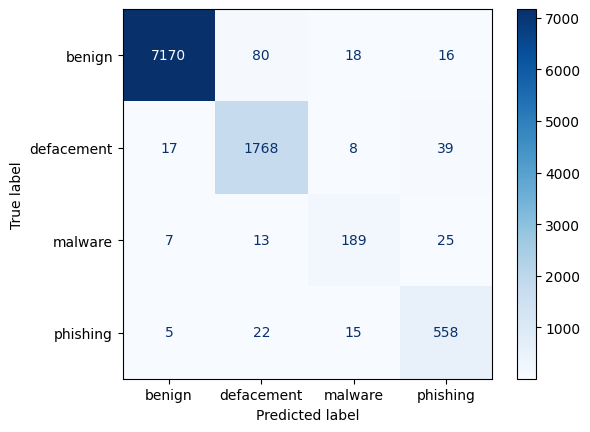

Numero di esempi analizzati: 9950
Somma elementi matrice: 9950


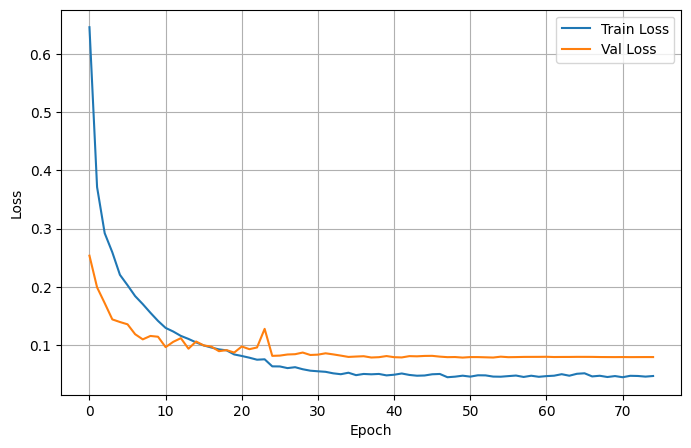

In [ ]:
import os, pickle, numpy as np, torch
import torch.nn as nn
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from torch.utils.data import TensorDataset, DataLoader, WeightedRandomSampler
import matplotlib.pyplot as plt
import random

# ---------------- CONFIGURAZIONE ----------------

SEED = 42

random.seed(SEED)

np.random.seed(SEED)

torch.manual_seed(SEED)

torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True

torch.backends.cudnn.benchmark = False

DATA_DIR = "/content/drive/MyDrive/"

REPORTS_DIR = "/content/models/reports"

MODEL_SAVE = "/content/models/best_model_embed.pth"

BATCH_SIZE = 64

EPOCHS = 100

ES_PATIENCE = 25

ES_MIN_DELTA = 0.0001

LR = 0.001

WD = 0.0001

os.makedirs(REPORTS_DIR, exist_ok=True)

device = "cuda" if torch.cuda.is_available() else "cpu"

print("Device:", device,"\n")

# ---------------- CARICAMENTO DATI ----------------

X = np.load(os.path.join(DATA_DIR, "X.npy"))
y = np.load(os.path.join(DATA_DIR, "y.npy"))

with open(os.path.join(DATA_DIR, "string_to_index.pkl"), "rb") as f:

    meta = pickle.load(f)

vocab_size = meta["vocab_size"]

PAD_IDX = meta["PAD"]

UNK = meta["UNK"]

labels = meta.get("labels", ["benign","defacement","malware","phishing"])

print(f"Dataset: X={X.shape}, y={y.shape}, vocab_size={vocab_size}","\n")

# ---------------- SPLIT ----------------

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.2, stratify=y_trainval, random_state=42
)

# ---------------- TORCH ----------------

X_train = torch.from_numpy(X_train).long()
X_val   = torch.from_numpy(X_val).long()
X_test  = torch.from_numpy(X_test).long()

y_train = torch.from_numpy(y_train).long()
y_val   = torch.from_numpy(y_val).long()
y_test  = torch.from_numpy(y_test).long()

# ---------------- STATISTICHE ----------------

def distr(Set_Name, y):

    c = Counter(y.tolist())

    tot = len(y)

    result = {}

    for key, value in sorted(c.items()):

        percentage = 100 * value / tot

        result[key] = f"{value} ({percentage:.1f}%)"

    print(Set_Name,result,"\n")

distr("Dataset: ", torch.from_numpy(y))

distr("Training Set: ", y_train)

distr("Validation Set: ", y_val)

distr("Test Set: ", y_test)

# ---------------- DATASET & SAMPLER ----------------

train_ds = TensorDataset(X_train, y_train)

val_ds   = TensorDataset(X_val, y_val)

test_ds  = TensorDataset(X_test, y_test)

num_classes = len(labels)

c = Counter(y_train.tolist())

class_counts = torch.tensor([c[i] for i in range(num_classes)], dtype=torch.float)

weights_per_class = 1.0 / class_counts

sample_weights = weights_per_class[y_train].to(torch.float)

sampler = WeightedRandomSampler(sample_weights,
                                num_samples=len(sample_weights), replacement=True)
pin_mem = (device == "cuda")

train_loader = DataLoader(train_ds,
                          batch_size = BATCH_SIZE,
                          sampler = sampler,
                          num_workers = 0,
                          pin_memory = pin_mem)

val_loader = DataLoader(val_ds,
                        batch_size = BATCH_SIZE,
                        shuffle = False,
                        num_workers = 0,
                        pin_memory = pin_mem)

test_loader = DataLoader(test_ds,
                         batch_size = BATCH_SIZE,
                         shuffle = False,
                         num_workers = 0,
                         pin_memory = pin_mem)

# ---------------- MODELLO ----------------

class MultiClassModel(nn.Module):

    def __init__(self, vocab_size, emb_dim = 64, num_classes = 4, pad_idx = 0):

        super().__init__()

        self.pad_idx = pad_idx

        self.emb = nn.Embedding(vocab_size,
                                emb_dim,
                                padding_idx = pad_idx)

        self.layer_stack = nn.Sequential(
            nn.Linear(emb_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.1),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.1),

            nn.Linear(64, num_classes)
        )

    def forward(self, x):

        E = self.emb(x)

        mask = (x != self.pad_idx).float()

        denom = mask.sum(dim = 1, keepdim = True).clamp_min(1.0)

        pooled = (E * mask.unsqueeze(-1)).sum(dim = 1) / denom

        return self.layer_stack(pooled)

model = MultiClassModel(vocab_size = vocab_size,
                        emb_dim = 128,
                        num_classes = num_classes,
                        pad_idx = PAD_IDX).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr = LR, weight_decay = WD)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3)

loss_fn = nn.CrossEntropyLoss()

# ---------------- TRAINING LOOP ----------------

best_val = float("inf")

es_wait = 0

train_losses, val_losses = [], []

def evaluate(loader):

    model.eval()

    loss_sum = 0.0

    n = 0

    y, all_preds = [], []

    with torch.inference_mode():

        for xb,yb in loader:

            xb, yb = xb.to(device), yb.to(device)

            logits = model(xb)

            loss = loss_fn(logits, yb)

            preds = logits.argmax(dim=1)

            m = yb.size(0)

            loss_sum += loss.item() * m

            n += m

            y.append(yb.cpu())

            all_preds.append(preds.cpu())

    y = torch.cat(y).numpy()

    all_preds = torch.cat(all_preds).numpy()

    return (loss_sum / n), y, all_preds

for epoch in range(EPOCHS):

    model.train()

    loss_sum = 0.0

    n = 0

    for xb, yb in train_loader:

        xb, yb = xb.to(device), yb.to(device)

        logits = model(xb)

        loss = loss_fn(logits, yb)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        m = yb.size(0)

        loss_sum += loss.item() * m

        n += m

    train_loss = loss_sum / n

    train_losses.append(train_loss)

    val_loss, y_val_np, p_val_np = evaluate(val_loader)

    val_losses.append(val_loss)

    scheduler.step(val_loss)

    improved = val_loss < ( best_val - ES_MIN_DELTA )

    if improved:

        best_val = val_loss

        es_wait = 0

        torch.save({"epoch": epoch, "model_state": model.state_dict(),
                    "optimizer_state": optimizer.state_dict(), "val_loss": best_val}, MODEL_SAVE)
    else:

        es_wait += 1

    lr = optimizer.param_groups[0]["lr"]

    print(f"Epoch {epoch:3d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | "
          f"lr={lr:.2e} | {'IMPROVED' if improved else f'no-improve({es_wait}/{ES_PATIENCE})'}")

    if epoch % 10 == 0:
        print("\nValidation report:")
        print(classification_report(y_val_np, p_val_np, target_names=labels, digits=4))

    if es_wait >= ES_PATIENCE:
        print(f"Early stopping a epoch {epoch+1}. Best val_loss={best_val:.6f}")
        break

# ---------------- TEST ----------------

test_loss, y_test, preds = evaluate(test_loader)

# Confusion matrix
cm = confusion_matrix(y_test, preds)
ConfusionMatrixDisplay(cm, display_labels=labels).plot(cmap="Blues")
plt.show()

print("Numero di esempi analizzati:", len(y_test))

print("Somma elementi matrice:", cm.sum())

# ---------------- PLOT ----------------

plt.figure(figsize=(8,5))

plt.plot(train_losses, label="Train Loss")

plt.plot(val_losses, label="Val Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid(True)

plt.show()

### 3.2 VERSION

Device: cuda 

Dataset: X=(49750, 250), y=(49750,), vocab_size=135 

Dataset:  {0: '36419 (73.2%)', 1: '9158 (18.4%)', 2: '1171 (2.4%)', 3: '3002 (6.0%)'} 

Training Set:  {0: '23308 (73.2%)', 1: '5861 (18.4%)', 2: '750 (2.4%)', 3: '1921 (6.0%)'} 

Validation Set:  {0: '5827 (73.2%)', 1: '1465 (18.4%)', 2: '187 (2.3%)', 3: '481 (6.0%)'} 

Test Set:  {0: '7284 (73.2%)', 1: '1832 (18.4%)', 2: '234 (2.4%)', 3: '600 (6.0%)'} 

Epoch   0 | train_loss=0.6838 | val_loss=0.2808 | lr=1.00e-03 | IMPROVED

Validation report:
              precision    recall  f1-score   support

      benign     0.9863    0.9274    0.9560      5827
  defacement     0.8342    0.9133    0.8719      1465
     malware     0.3492    0.6684    0.4587       187
    phishing     0.7495    0.8087    0.7780       481

    accuracy                         0.9116      7960
   macro avg     0.7298    0.8295    0.7662      7960
weighted avg     0.9290    0.9116    0.9181      7960

Epoch   1 | train_loss=0.3997 | val_loss=0.18

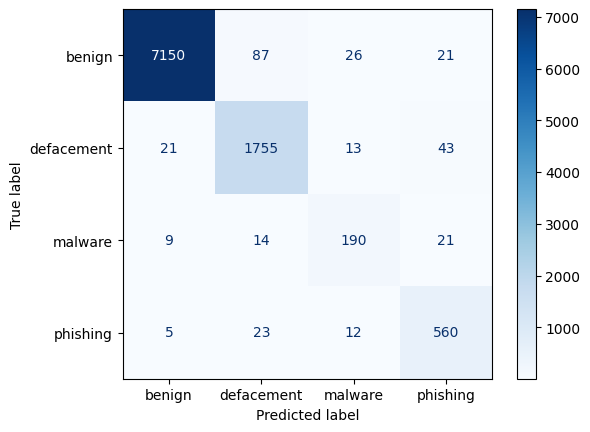

Numero di esempi analizzati: 9950
Somma elementi matrice: 9950


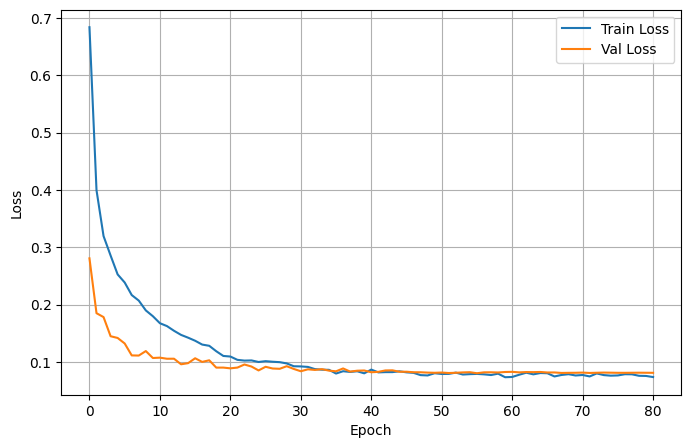

In [ ]:
import os, pickle, numpy as np, torch
import torch.nn as nn
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from torch.utils.data import TensorDataset, DataLoader, WeightedRandomSampler
import matplotlib.pyplot as plt
import random

# ---------------- CONFIGURAZIONE ----------------

SEED = 42

random.seed(SEED)

np.random.seed(SEED)

torch.manual_seed(SEED)

torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True

torch.backends.cudnn.benchmark = False

DATA_DIR = "/content/drive/MyDrive/"

REPORTS_DIR = "/content/models/reports"

MODEL_SAVE = "/content/models/best_model_embed.pth"

BATCH_SIZE = 64

EPOCHS = 100

SWITCH_EPOCH = 20

ES_PATIENCE = 25

ES_MIN_DELTA = 0.0001

LR = 0.001

WD = 0.0001

os.makedirs(REPORTS_DIR, exist_ok=True)

device = "cuda" if torch.cuda.is_available() else "cpu"

print("Device:", device,"\n")

# ---------------- CARICAMENTO DATI ----------------

X = np.load(os.path.join(DATA_DIR, "X.npy"))
y = np.load(os.path.join(DATA_DIR, "y.npy"))

with open(os.path.join(DATA_DIR, "string_to_index.pkl"), "rb") as f:

    meta = pickle.load(f)

vocab_size = meta["vocab_size"]

PAD_IDX = meta["PAD"]

UNK = meta["UNK"]

labels = meta.get("labels", ["benign","defacement","malware","phishing"])

print(f"Dataset: X={X.shape}, y={y.shape}, vocab_size={vocab_size}","\n")

# ---------------- SPLIT ----------------

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.2, stratify=y_trainval, random_state=42
)

# ---------------- TORCH ----------------

X_train = torch.from_numpy(X_train).long()
X_val   = torch.from_numpy(X_val).long()
X_test  = torch.from_numpy(X_test).long()

y_train = torch.from_numpy(y_train).long()
y_val   = torch.from_numpy(y_val).long()
y_test  = torch.from_numpy(y_test).long()

# ---------------- STATISTICHE ----------------

def distr(Set_Name, y):

    c = Counter(y.tolist())

    tot = len(y)

    result = {}

    for key, value in sorted(c.items()):

        percentage = 100 * value / tot

        result[key] = f"{value} ({percentage:.1f}%)"

    print(Set_Name,result,"\n")

distr("Dataset: ", torch.from_numpy(y))

distr("Training Set: ", y_train)

distr("Validation Set: ", y_val)

distr("Test Set: ", y_test)

# ---------------- DATASET & SAMPLER ----------------

train_ds = TensorDataset(X_train, y_train)

val_ds   = TensorDataset(X_val, y_val)

test_ds  = TensorDataset(X_test, y_test)

num_classes = len(labels)

c = Counter(y_train.tolist())

class_counts = torch.tensor([c[i] for i in range(num_classes)], dtype=torch.float)

weights_per_class = 1.0 / class_counts

sample_weights = weights_per_class[y_train].to(torch.float)

sampler = WeightedRandomSampler(sample_weights,
                                num_samples=len(sample_weights), replacement=True)
pin_mem = (device == "cuda")

train_loader = DataLoader(train_ds,
                          batch_size = BATCH_SIZE,
                          sampler = sampler,
                          num_workers = 0,
                          pin_memory = pin_mem)

val_loader = DataLoader(val_ds,
                        batch_size = BATCH_SIZE,
                        shuffle = False,
                        num_workers = 0,
                        pin_memory = pin_mem)

test_loader = DataLoader(test_ds,
                         batch_size = BATCH_SIZE,
                         shuffle = False,
                         num_workers = 0,
                         pin_memory = pin_mem)

# ---------------- MODELLO ----------------

class MultiClassModel(nn.Module):

    def __init__(self, vocab_size, emb_dim = 64, num_classes = 4, pad_idx = 0):

        super().__init__()

        self.pad_idx = pad_idx

        self.emb = nn.Embedding(vocab_size,
                                emb_dim,
                                padding_idx = pad_idx)

        self.layer_stack = nn.Sequential(
            nn.Linear(emb_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.25),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.25),

            nn.Linear(64, num_classes)
        )

    def forward(self, x):

        E = self.emb(x)

        mask = (x != self.pad_idx).float()

        denom = mask.sum(dim = 1, keepdim = True).clamp_min(1.0)

        pooled = (E * mask.unsqueeze(-1)).sum(dim = 1) / denom

        return self.layer_stack(pooled)

model = MultiClassModel(vocab_size = vocab_size,
                        emb_dim = 128,
                        num_classes = num_classes,
                        pad_idx = PAD_IDX).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr = LR, weight_decay = WD)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3)

loss_fn = nn.CrossEntropyLoss()

# ---------------- TRAINING LOOP ----------------

best_val = float("inf")

es_wait = 0

train_losses, val_losses = [], []

def evaluate(loader):

    model.eval()

    loss_sum = 0.0

    n = 0

    y, all_preds = [], []

    with torch.inference_mode():

        for xb,yb in loader:

            xb, yb = xb.to(device), yb.to(device)

            logits = model(xb)

            loss = loss_fn(logits, yb)

            preds = logits.argmax(dim=1)

            m = yb.size(0)

            loss_sum += loss.item() * m

            n += m

            y.append(yb.cpu())

            all_preds.append(preds.cpu())

    y = torch.cat(y).numpy()

    all_preds = torch.cat(all_preds).numpy()

    return (loss_sum / n), y, all_preds

for epoch in range(EPOCHS):

    model.train()

    loss_sum = 0.0

    n = 0

    for xb, yb in train_loader:

        xb, yb = xb.to(device), yb.to(device)

        logits = model(xb)

        loss = loss_fn(logits, yb)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        m = yb.size(0)

        loss_sum += loss.item() * m

        n += m

    train_loss = loss_sum / n

    train_losses.append(train_loss)

    val_loss, y_val_np, p_val_np = evaluate(val_loader)

    val_losses.append(val_loss)

    scheduler.step(val_loss)

    improved = val_loss < ( best_val - ES_MIN_DELTA )

    if improved:

        best_val = val_loss

        es_wait = 0

        torch.save({"epoch": epoch, "model_state": model.state_dict(),
                    "optimizer_state": optimizer.state_dict(), "val_loss": best_val}, MODEL_SAVE)
    else:

        es_wait += 1

    lr = optimizer.param_groups[0]["lr"]

    print(f"Epoch {epoch:3d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | "
          f"lr={lr:.2e} | {'IMPROVED' if improved else f'no-improve({es_wait}/{ES_PATIENCE})'}")

    if epoch % 10 == 0:
        print("\nValidation report:")
        print(classification_report(y_val_np, p_val_np, target_names=labels, digits=4))

    if es_wait >= ES_PATIENCE:
        print(f"Early stopping a epoch {epoch+1}. Best val_loss={best_val:.6f}")
        break

# ---------------- TEST ----------------

test_loss, y_test, preds = evaluate(test_loader)

# Confusion matrix
cm = confusion_matrix(y_test, preds)
ConfusionMatrixDisplay(cm, display_labels=labels).plot(cmap="Blues")
plt.show()

print("Numero di esempi analizzati:", len(y_test))

print("Somma elementi matrice:", cm.sum())

# ---------------- PLOT ----------------

plt.figure(figsize=(8,5))

plt.plot(train_losses, label="Train Loss")

plt.plot(val_losses, label="Val Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid(True)

plt.show()

### 3.3 VERSION

Device: cuda 

Dataset: X=(49750, 250), y=(49750,), vocab_size=135 

Dataset:  {0: '36419 (73.2%)', 1: '9158 (18.4%)', 2: '1171 (2.4%)', 3: '3002 (6.0%)'} 

Training Set:  {0: '23308 (73.2%)', 1: '5861 (18.4%)', 2: '750 (2.4%)', 3: '1921 (6.0%)'} 

Validation Set:  {0: '5827 (73.2%)', 1: '1465 (18.4%)', 2: '187 (2.3%)', 3: '481 (6.0%)'} 

Test Set:  {0: '7284 (73.2%)', 1: '1832 (18.4%)', 2: '234 (2.4%)', 3: '600 (6.0%)'} 

Epoch   0 | train_loss=0.7154 | val_loss=0.3004 | lr=1.00e-03 | IMPROVED

Validation report:
              precision    recall  f1-score   support

      benign     0.9842    0.9219    0.9521      5827
  defacement     0.8126    0.9263    0.8657      1465
     malware     0.3307    0.6791    0.4448       187
    phishing     0.8058    0.7505    0.7772       481

    accuracy                         0.9067      7960
   macro avg     0.7333    0.8195    0.7599      7960
weighted avg     0.9265    0.9067    0.9137      7960

Epoch   1 | train_loss=0.4327 | val_loss=0.20

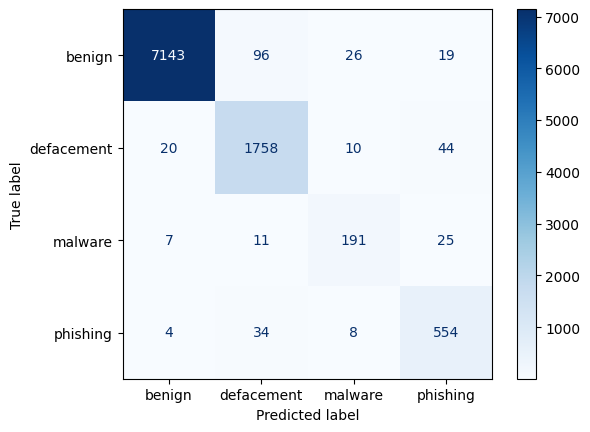

Numero di esempi analizzati: 9950
Somma elementi matrice: 9950


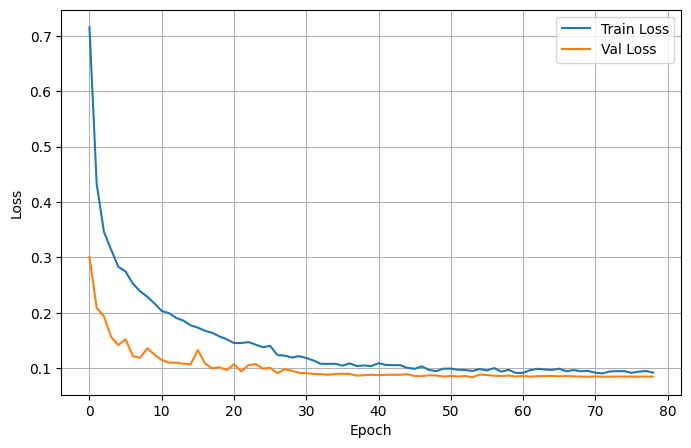

In [ ]:
import os, pickle, numpy as np, torch
import torch.nn as nn
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from torch.utils.data import TensorDataset, DataLoader, WeightedRandomSampler
import matplotlib.pyplot as plt
import random

# ---------------- CONFIGURAZIONE ----------------

SEED = 42

random.seed(SEED)

np.random.seed(SEED)

torch.manual_seed(SEED)

torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True

torch.backends.cudnn.benchmark = False

DATA_DIR = "/content/drive/MyDrive/"

REPORTS_DIR = "/content/models/reports"

MODEL_SAVE = "/content/models/best_model_embed.pth"

BATCH_SIZE = 64

EPOCHS = 100

ES_PATIENCE = 25

ES_MIN_DELTA = 0.0001

LR = 0.001

WD = 0.0001

os.makedirs(REPORTS_DIR, exist_ok=True)

device = "cuda" if torch.cuda.is_available() else "cpu"

print("Device:", device,"\n")

# ---------------- CARICAMENTO DATI ----------------

X = np.load(os.path.join(DATA_DIR, "X.npy"))
y = np.load(os.path.join(DATA_DIR, "y.npy"))

with open(os.path.join(DATA_DIR, "string_to_index.pkl"), "rb") as f:

    meta = pickle.load(f)

vocab_size = meta["vocab_size"]

PAD_IDX = meta["PAD"]

UNK = meta["UNK"]

labels = meta.get("labels", ["benign","defacement","malware","phishing"])

print(f"Dataset: X={X.shape}, y={y.shape}, vocab_size={vocab_size}","\n")

# ---------------- SPLIT ----------------

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.2, stratify=y_trainval, random_state=42
)

# ---------------- TORCH ----------------

X_train = torch.from_numpy(X_train).long()
X_val   = torch.from_numpy(X_val).long()
X_test  = torch.from_numpy(X_test).long()

y_train = torch.from_numpy(y_train).long()
y_val   = torch.from_numpy(y_val).long()
y_test  = torch.from_numpy(y_test).long()

# ---------------- STATISTICHE ----------------

def distr(Set_Name, y):

    c = Counter(y.tolist())

    tot = len(y)

    result = {}

    for key, value in sorted(c.items()):

        percentage = 100 * value / tot

        result[key] = f"{value} ({percentage:.1f}%)"

    print(Set_Name,result,"\n")

distr("Dataset: ", torch.from_numpy(y))

distr("Training Set: ", y_train)

distr("Validation Set: ", y_val)

distr("Test Set: ", y_test)

# ---------------- DATASET & SAMPLER ----------------

train_ds = TensorDataset(X_train, y_train)

val_ds   = TensorDataset(X_val, y_val)

test_ds  = TensorDataset(X_test, y_test)

num_classes = len(labels)

c = Counter(y_train.tolist())

class_counts = torch.tensor([c[i] for i in range(num_classes)], dtype=torch.float)

weights_per_class = 1.0 / class_counts

sample_weights = weights_per_class[y_train].to(torch.float)

sampler = WeightedRandomSampler(sample_weights,
                                num_samples=len(sample_weights), replacement=True)
pin_mem = (device == "cuda")

train_loader = DataLoader(train_ds,
                          batch_size = BATCH_SIZE,
                          sampler = sampler,
                          num_workers = 0,
                          pin_memory = pin_mem)

val_loader = DataLoader(val_ds,
                        batch_size = BATCH_SIZE,
                        shuffle = False,
                        num_workers = 0,
                        pin_memory = pin_mem)

test_loader = DataLoader(test_ds,
                         batch_size = BATCH_SIZE,
                         shuffle = False,
                         num_workers = 0,
                         pin_memory = pin_mem)

# ---------------- MODELLO ----------------

class MultiClassModel(nn.Module):

    def __init__(self, vocab_size, emb_dim = 64, num_classes = 4, pad_idx = 0):

        super().__init__()

        self.pad_idx = pad_idx

        self.emb = nn.Embedding(vocab_size,
                                emb_dim,
                                padding_idx = pad_idx)

        self.layer_stack = nn.Sequential(
            nn.Linear(emb_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.35),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.35),

            nn.Linear(64, num_classes)
        )

    def forward(self, x):

        E = self.emb(x)

        mask = (x != self.pad_idx).float()

        denom = mask.sum(dim = 1, keepdim = True).clamp_min(1.0)

        pooled = (E * mask.unsqueeze(-1)).sum(dim = 1) / denom

        return self.layer_stack(pooled)

model = MultiClassModel(vocab_size = vocab_size,
                        emb_dim = 128,
                        num_classes = num_classes,
                        pad_idx = PAD_IDX).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr = LR, weight_decay = WD)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3)

loss_fn = nn.CrossEntropyLoss()

# ---------------- TRAINING LOOP ----------------

best_val = float("inf")

es_wait = 0

train_losses, val_losses = [], []

def evaluate(loader):

    model.eval()

    loss_sum = 0.0

    n = 0

    y, all_preds = [], []

    with torch.inference_mode():

        for xb,yb in loader:

            xb, yb = xb.to(device), yb.to(device)

            logits = model(xb)

            loss = loss_fn(logits, yb)

            preds = logits.argmax(dim=1)

            m = yb.size(0)

            loss_sum += loss.item() * m

            n += m

            y.append(yb.cpu())

            all_preds.append(preds.cpu())

    y = torch.cat(y).numpy()

    all_preds = torch.cat(all_preds).numpy()

    return (loss_sum / n), y, all_preds

for epoch in range(EPOCHS):

    model.train()

    loss_sum = 0.0

    n = 0

    for xb, yb in train_loader:

        xb, yb = xb.to(device), yb.to(device)

        logits = model(xb)

        loss = loss_fn(logits, yb)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        m = yb.size(0)

        loss_sum += loss.item() * m

        n += m

    train_loss = loss_sum / n

    train_losses.append(train_loss)

    val_loss, y_val_np, p_val_np = evaluate(val_loader)

    val_losses.append(val_loss)

    scheduler.step(val_loss)

    improved = val_loss < ( best_val - ES_MIN_DELTA )

    if improved:

        best_val = val_loss

        es_wait = 0

        torch.save({"epoch": epoch, "model_state": model.state_dict(),
                    "optimizer_state": optimizer.state_dict(), "val_loss": best_val}, MODEL_SAVE)
    else:

        es_wait += 1

    lr = optimizer.param_groups[0]["lr"]

    print(f"Epoch {epoch:3d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | "
          f"lr={lr:.2e} | {'IMPROVED' if improved else f'no-improve({es_wait}/{ES_PATIENCE})'}")

    if epoch % 10 == 0:
        print("\nValidation report:")
        print(classification_report(y_val_np, p_val_np, target_names=labels, digits=4))

    if es_wait >= ES_PATIENCE:
        print(f"Early stopping a epoch {epoch+1}. Best val_loss={best_val:.6f}")
        break

# ---------------- TEST ----------------

test_loss, y_test, preds = evaluate(test_loader)

# Confusion matrix
cm = confusion_matrix(y_test, preds)
ConfusionMatrixDisplay(cm, display_labels=labels).plot(cmap="Blues")
plt.show()

print("Numero di esempi analizzati:", len(y_test))

print("Somma elementi matrice:", cm.sum())

# ---------------- PLOT ----------------

plt.figure(figsize=(8,5))

plt.plot(train_losses, label="Train Loss")

plt.plot(val_losses, label="Val Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid(True)

plt.show()

### 3.4 VERSION

Device: cuda 

Dataset: X=(49750, 250), y=(49750,), vocab_size=135 

Dataset:  {0: '36419 (73.2%)', 1: '9158 (18.4%)', 2: '1171 (2.4%)', 3: '3002 (6.0%)'} 

Training Set:  {0: '23308 (73.2%)', 1: '5861 (18.4%)', 2: '750 (2.4%)', 3: '1921 (6.0%)'} 

Validation Set:  {0: '5827 (73.2%)', 1: '1465 (18.4%)', 2: '187 (2.3%)', 3: '481 (6.0%)'} 

Test Set:  {0: '7284 (73.2%)', 1: '1832 (18.4%)', 2: '234 (2.4%)', 3: '600 (6.0%)'} 

Epoch   0 | train_loss=0.6328 | val_loss=0.2732 | lr=1.00e-03 | IMPROVED

Validation report:
              precision    recall  f1-score   support

      benign     0.9889    0.9360    0.9617      5827
  defacement     0.9126    0.8266    0.8675      1465
     malware     0.2865    0.8289    0.4258       187
    phishing     0.6880    0.8254    0.7505       481

    accuracy                         0.9067      7960
   macro avg     0.7190    0.8542    0.7514      7960
weighted avg     0.9402    0.9067    0.9190      7960

Epoch   1 | train_loss=0.3344 | val_loss=0.16

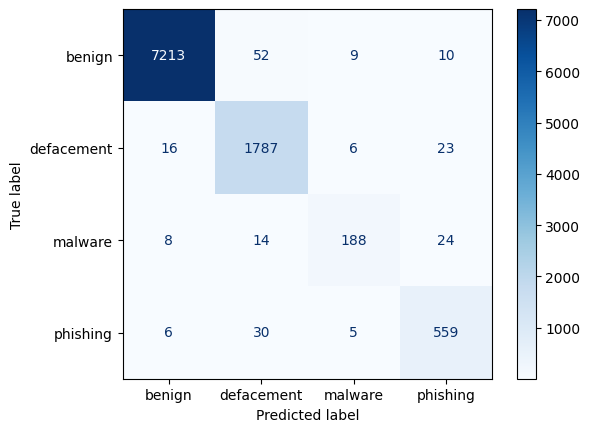

Numero di esempi analizzati: 9950
Somma elementi matrice: 9950


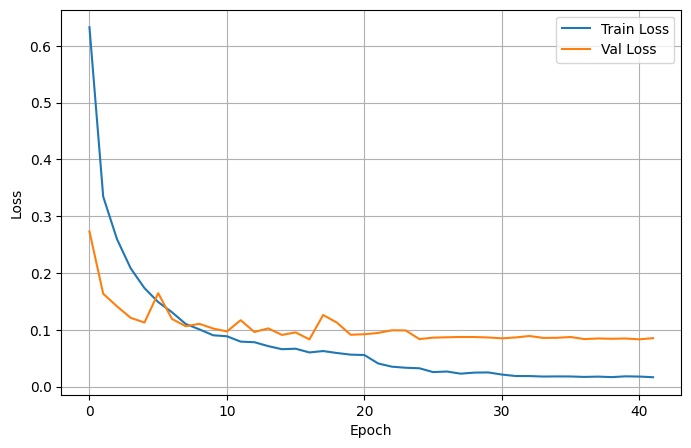

In [ ]:
import os, pickle, numpy as np, torch
import torch.nn as nn
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from torch.utils.data import TensorDataset, DataLoader, WeightedRandomSampler
import matplotlib.pyplot as plt
import random

# ---------------- CONFIGURAZIONE ----------------

SEED = 42

random.seed(SEED)

np.random.seed(SEED)

torch.manual_seed(SEED)

torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True

torch.backends.cudnn.benchmark = False

DATA_DIR = "/content/drive/MyDrive/"

REPORTS_DIR = "/content/models/reports"

MODEL_SAVE = "/content/models/best_model_embed.pth"

BATCH_SIZE = 64

EPOCHS = 100

ES_PATIENCE = 25

ES_MIN_DELTA = 0.0001

LR = 0.001

WD = 0.0001

os.makedirs(REPORTS_DIR, exist_ok=True)

device = "cuda" if torch.cuda.is_available() else "cpu"

print("Device:", device,"\n")

# ---------------- CARICAMENTO DATI ----------------

X = np.load(os.path.join(DATA_DIR, "X.npy"))
y = np.load(os.path.join(DATA_DIR, "y.npy"))

with open(os.path.join(DATA_DIR, "string_to_index.pkl"), "rb") as f:

    meta = pickle.load(f)

vocab_size = meta["vocab_size"]

PAD_IDX = meta["PAD"]

UNK = meta["UNK"]

labels = meta.get("labels", ["benign","defacement","malware","phishing"])

print(f"Dataset: X={X.shape}, y={y.shape}, vocab_size={vocab_size}","\n")

# ---------------- SPLIT ----------------

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.2, stratify=y_trainval, random_state=42
)

# ---------------- TORCH ----------------

X_train = torch.from_numpy(X_train).long()
X_val   = torch.from_numpy(X_val).long()
X_test  = torch.from_numpy(X_test).long()

y_train = torch.from_numpy(y_train).long()
y_val   = torch.from_numpy(y_val).long()
y_test  = torch.from_numpy(y_test).long()

# ---------------- STATISTICHE ----------------

def distr(Set_Name, y):

    c = Counter(y.tolist())

    tot = len(y)

    result = {}

    for key, value in sorted(c.items()):

        percentage = 100 * value / tot

        result[key] = f"{value} ({percentage:.1f}%)"

    print(Set_Name,result,"\n")

distr("Dataset: ", torch.from_numpy(y))

distr("Training Set: ", y_train)

distr("Validation Set: ", y_val)

distr("Test Set: ", y_test)

# ---------------- DATASET & SAMPLER ----------------

train_ds = TensorDataset(X_train, y_train)

val_ds   = TensorDataset(X_val, y_val)

test_ds  = TensorDataset(X_test, y_test)

num_classes = len(labels)

c = Counter(y_train.tolist())

class_counts = torch.tensor([c[i] for i in range(num_classes)], dtype=torch.float)

weights_per_class = 1.0 / class_counts

sample_weights = weights_per_class[y_train].to(torch.float)

sampler = WeightedRandomSampler(sample_weights,
                                num_samples=len(sample_weights), replacement=True)
pin_mem = (device == "cuda")

train_loader = DataLoader(train_ds,
                          batch_size = BATCH_SIZE,
                          sampler = sampler,
                          num_workers = 0,
                          pin_memory = pin_mem)

val_loader = DataLoader(val_ds,
                        batch_size = BATCH_SIZE,
                        shuffle = False,
                        num_workers = 0,
                        pin_memory = pin_mem)

test_loader = DataLoader(test_ds,
                         batch_size = BATCH_SIZE,
                         shuffle = False,
                         num_workers = 0,
                         pin_memory = pin_mem)

# ---------------- MODELLO ----------------

class MultiClassModel(nn.Module):

    def __init__(self, vocab_size, emb_dim = 64, num_classes = 4, pad_idx = 0):

        super().__init__()

        self.pad_idx = pad_idx

        self.emb = nn.Embedding(vocab_size,
                                emb_dim,
                                padding_idx = pad_idx)

        self.layer_stack = nn.Sequential(
            nn.Linear(emb_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.1),

            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.35),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(64, num_classes)
        )

    def forward(self, x):

        E = self.emb(x)

        mask = (x != self.pad_idx).float()

        denom = mask.sum(dim = 1, keepdim = True).clamp_min(1.0)

        pooled = (E * mask.unsqueeze(-1)).sum(dim = 1) / denom

        return self.layer_stack(pooled)

model = MultiClassModel(vocab_size = vocab_size,
                        emb_dim = 128,
                        num_classes = num_classes,
                        pad_idx = PAD_IDX).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr = LR, weight_decay = WD)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3)

loss_fn = nn.CrossEntropyLoss()

# ---------------- TRAINING LOOP ----------------

best_val = float("inf")

es_wait = 0

train_losses, val_losses = [], []

def evaluate(loader):

    model.eval()

    loss_sum = 0.0

    n = 0

    y, all_preds = [], []

    with torch.inference_mode():

        for xb,yb in loader:

            xb, yb = xb.to(device), yb.to(device)

            logits = model(xb)

            loss = loss_fn(logits, yb)

            preds = logits.argmax(dim=1)

            m = yb.size(0)

            loss_sum += loss.item() * m

            n += m

            y.append(yb.cpu())

            all_preds.append(preds.cpu())

    y = torch.cat(y).numpy()

    all_preds = torch.cat(all_preds).numpy()

    return (loss_sum / n), y, all_preds

for epoch in range(EPOCHS):

    model.train()

    loss_sum = 0.0

    n = 0

    for xb, yb in train_loader:

        xb, yb = xb.to(device), yb.to(device)

        logits = model(xb)

        loss = loss_fn(logits, yb)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        m = yb.size(0)

        loss_sum += loss.item() * m

        n += m

    train_loss = loss_sum / n

    train_losses.append(train_loss)

    val_loss, y_val_np, p_val_np = evaluate(val_loader)

    val_losses.append(val_loss)

    scheduler.step(val_loss)

    improved = val_loss < ( best_val - ES_MIN_DELTA )

    if improved:

        best_val = val_loss

        es_wait = 0

        torch.save({"epoch": epoch, "model_state": model.state_dict(),
                    "optimizer_state": optimizer.state_dict(), "val_loss": best_val}, MODEL_SAVE)
    else:

        es_wait += 1

    lr = optimizer.param_groups[0]["lr"]

    print(f"Epoch {epoch:3d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | "
          f"lr={lr:.2e} | {'IMPROVED' if improved else f'no-improve({es_wait}/{ES_PATIENCE})'}")

    if epoch % 10 == 0:
        print("\nValidation report:")
        print(classification_report(y_val_np, p_val_np, target_names=labels, digits=4))

    if es_wait >= ES_PATIENCE:
        print(f"Early stopping a epoch {epoch+1}. Best val_loss={best_val:.6f}")
        break

# ---------------- TEST ----------------

test_loss, y_test, preds = evaluate(test_loader)

# Confusion matrix
cm = confusion_matrix(y_test, preds)
ConfusionMatrixDisplay(cm, display_labels=labels).plot(cmap="Blues")
plt.show()

print("Numero di esempi analizzati:", len(y_test))

print("Somma elementi matrice:", cm.sum())

# ---------------- PLOT ----------------

plt.figure(figsize=(8,5))

plt.plot(train_losses, label="Train Loss")

plt.plot(val_losses, label="Val Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid(True)

plt.show()

### 3.5 VERSION

Device: cuda 

Dataset: X=(49750, 250), y=(49750,), vocab_size=135 

Dataset:  {0: '36419 (73.2%)', 1: '9158 (18.4%)', 2: '1171 (2.4%)', 3: '3002 (6.0%)'} 

Training Set:  {0: '23308 (73.2%)', 1: '5861 (18.4%)', 2: '750 (2.4%)', 3: '1921 (6.0%)'} 

Validation Set:  {0: '5827 (73.2%)', 1: '1465 (18.4%)', 2: '187 (2.3%)', 3: '481 (6.0%)'} 

Test Set:  {0: '7284 (73.2%)', 1: '1832 (18.4%)', 2: '234 (2.4%)', 3: '600 (6.0%)'} 

Epoch   0 | train_loss=0.6792 | val_loss=0.3016 | lr=1.00e-03 | IMPROVED

Validation report:
              precision    recall  f1-score   support

      benign     0.9872    0.9279    0.9567      5827
  defacement     0.9019    0.8532    0.8769      1465
     malware     0.2450    0.8449    0.3798       187
    phishing     0.7876    0.7401    0.7631       481

    accuracy                         0.9009      7960
   macro avg     0.7304    0.8416    0.7441      7960
weighted avg     0.9420    0.9009    0.9167      7960

Epoch   1 | train_loss=0.3794 | val_loss=0.17

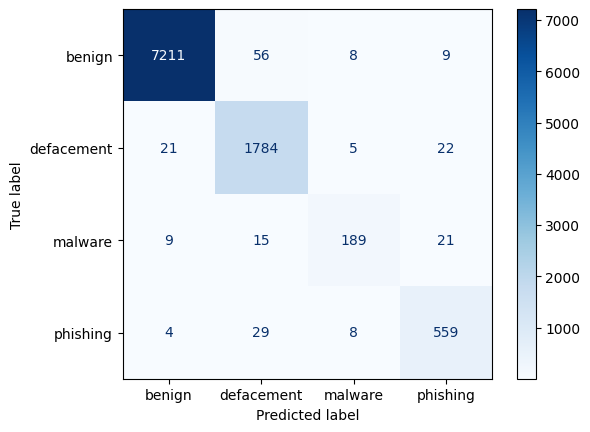

Numero di esempi analizzati: 9950
Somma elementi matrice: 9950


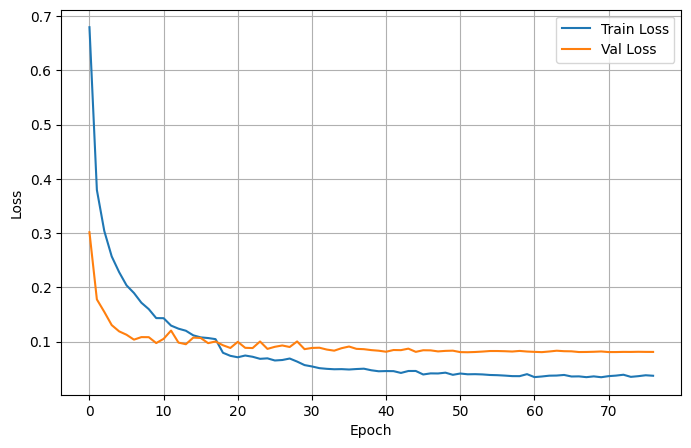

In [ ]:
import os, pickle, numpy as np, torch
import torch.nn as nn
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from torch.utils.data import TensorDataset, DataLoader, WeightedRandomSampler
import matplotlib.pyplot as plt
import random

# ---------------- CONFIGURAZIONE ----------------

SEED = 42

random.seed(SEED)

np.random.seed(SEED)

torch.manual_seed(SEED)

torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True

torch.backends.cudnn.benchmark = False

DATA_DIR = "/content/drive/MyDrive/"

REPORTS_DIR = "/content/models/reports"

MODEL_SAVE = "/content/models/best_model_embed.pth"

BATCH_SIZE = 64

EPOCHS = 100

ES_PATIENCE = 25

ES_MIN_DELTA = 0.0001

LR = 0.001

WD = 0.0001

os.makedirs(REPORTS_DIR, exist_ok=True)

device = "cuda" if torch.cuda.is_available() else "cpu"

print("Device:", device,"\n")

# ---------------- CARICAMENTO DATI ----------------

X = np.load(os.path.join(DATA_DIR, "X.npy"))
y = np.load(os.path.join(DATA_DIR, "y.npy"))

with open(os.path.join(DATA_DIR, "string_to_index.pkl"), "rb") as f:

    meta = pickle.load(f)

vocab_size = meta["vocab_size"]

PAD_IDX = meta["PAD"]

UNK = meta["UNK"]

labels = meta.get("labels", ["benign","defacement","malware","phishing"])

print(f"Dataset: X={X.shape}, y={y.shape}, vocab_size={vocab_size}","\n")

# ---------------- SPLIT ----------------

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.2, stratify=y_trainval, random_state=42
)

# ---------------- TORCH ----------------

X_train = torch.from_numpy(X_train).long()
X_val   = torch.from_numpy(X_val).long()
X_test  = torch.from_numpy(X_test).long()

y_train = torch.from_numpy(y_train).long()
y_val   = torch.from_numpy(y_val).long()
y_test  = torch.from_numpy(y_test).long()

# ---------------- STATISTICHE ----------------

def distr(Set_Name, y):

    c = Counter(y.tolist())

    tot = len(y)

    result = {}

    for key, value in sorted(c.items()):

        percentage = 100 * value / tot

        result[key] = f"{value} ({percentage:.1f}%)"

    print(Set_Name,result,"\n")

distr("Dataset: ", torch.from_numpy(y))

distr("Training Set: ", y_train)

distr("Validation Set: ", y_val)

distr("Test Set: ", y_test)

# ---------------- DATASET & SAMPLER ----------------

train_ds = TensorDataset(X_train, y_train)

val_ds   = TensorDataset(X_val, y_val)

test_ds  = TensorDataset(X_test, y_test)

num_classes = len(labels)

c = Counter(y_train.tolist())

class_counts = torch.tensor([c[i] for i in range(num_classes)], dtype=torch.float)

weights_per_class = 1.0 / class_counts

sample_weights = weights_per_class[y_train].to(torch.float)

sampler = WeightedRandomSampler(sample_weights,
                                num_samples=len(sample_weights), replacement=True)
pin_mem = (device == "cuda")

train_loader = DataLoader(train_ds,
                          batch_size = BATCH_SIZE,
                          sampler = sampler,
                          num_workers = 0,
                          pin_memory = pin_mem)

val_loader = DataLoader(val_ds,
                        batch_size = BATCH_SIZE,
                        shuffle = False,
                        num_workers = 0,
                        pin_memory = pin_mem)

test_loader = DataLoader(test_ds,
                         batch_size = BATCH_SIZE,
                         shuffle = False,
                         num_workers = 0,
                         pin_memory = pin_mem)

# ---------------- MODELLO ----------------

class MultiClassModel(nn.Module):

    def __init__(self, vocab_size, emb_dim = 64, num_classes = 4, pad_idx = 0):

        super().__init__()

        self.pad_idx = pad_idx

        self.emb = nn.Embedding(vocab_size,
                                emb_dim,
                                padding_idx = pad_idx)

        self.layer_stack = nn.Sequential(
            nn.Linear(emb_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.25),

            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.4),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(64, num_classes)
        )

    def forward(self, x):

        E = self.emb(x)

        mask = (x != self.pad_idx).float()

        denom = mask.sum(dim = 1, keepdim = True).clamp_min(1.0)

        pooled = (E * mask.unsqueeze(-1)).sum(dim = 1) / denom

        return self.layer_stack(pooled)

model = MultiClassModel(vocab_size = vocab_size,
                        emb_dim = 128,
                        num_classes = num_classes,
                        pad_idx = PAD_IDX).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr = LR, weight_decay = WD)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3)

loss_fn = nn.CrossEntropyLoss()

# ---------------- TRAINING LOOP ----------------

best_val = float("inf")

es_wait = 0

train_losses, val_losses = [], []

def evaluate(loader):

    model.eval()

    loss_sum = 0.0

    n = 0

    y, all_preds = [], []

    with torch.inference_mode():

        for xb,yb in loader:

            xb, yb = xb.to(device), yb.to(device)

            logits = model(xb)

            loss = loss_fn(logits, yb)

            preds = logits.argmax(dim=1)

            m = yb.size(0)

            loss_sum += loss.item() * m

            n += m

            y.append(yb.cpu())

            all_preds.append(preds.cpu())

    y = torch.cat(y).numpy()

    all_preds = torch.cat(all_preds).numpy()

    return (loss_sum / n), y, all_preds

for epoch in range(EPOCHS):

    model.train()

    loss_sum = 0.0

    n = 0

    for xb, yb in train_loader:

        xb, yb = xb.to(device), yb.to(device)

        logits = model(xb)

        loss = loss_fn(logits, yb)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        m = yb.size(0)

        loss_sum += loss.item() * m

        n += m

    train_loss = loss_sum / n

    train_losses.append(train_loss)

    val_loss, y_val_np, p_val_np = evaluate(val_loader)

    val_losses.append(val_loss)

    scheduler.step(val_loss)

    improved = val_loss < ( best_val - ES_MIN_DELTA )

    if improved:

        best_val = val_loss

        es_wait = 0

        torch.save({"epoch": epoch, "model_state": model.state_dict(),
                    "optimizer_state": optimizer.state_dict(), "val_loss": best_val}, MODEL_SAVE)
    else:

        es_wait += 1

    lr = optimizer.param_groups[0]["lr"]

    print(f"Epoch {epoch:3d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | "
          f"lr={lr:.2e} | {'IMPROVED' if improved else f'no-improve({es_wait}/{ES_PATIENCE})'}")

    if epoch % 10 == 0:
        print("\nValidation report:")
        print(classification_report(y_val_np, p_val_np, target_names=labels, digits=4))

    if es_wait >= ES_PATIENCE:
        print(f"Early stopping a epoch {epoch+1}. Best val_loss={best_val:.6f}")
        break

# ---------------- TEST ----------------

test_loss, y_test, preds = evaluate(test_loader)

# Confusion matrix
cm = confusion_matrix(y_test, preds)
ConfusionMatrixDisplay(cm, display_labels=labels).plot(cmap="Blues")
plt.show()

print("Numero di esempi analizzati:", len(y_test))

print("Somma elementi matrice:", cm.sum())

# ---------------- PLOT ----------------

plt.figure(figsize=(8,5))

plt.plot(train_losses, label="Train Loss")

plt.plot(val_losses, label="Val Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid(True)

plt.show()